In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    DataCollatorForLanguageModeling,
    EvalPrediction
)
from sklearn.metrics import accuracy_score, f1_score

import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

torch.cuda.empty_cache()

torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cuda')

In [2]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

encoder = LabelEncoder()
encoder.classes_ = np.load("../models/hateXplain/classes.npy", allow_pickle=True)

print(len(encoder.classes_))
print(encoder.classes_)

3
['hatespeech' 'normal' 'offensive']


In [3]:
import json

with open("../models/hateXplain/dataset.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

from collections import Counter


def get_majority_label(annotators):
    labels = [a["label"] for a in annotators]
    most_common = Counter(labels).most_common(1)
    return most_common[0][0] if most_common else None


texts, labels = [], []

for post_id, post_data in raw_data.items():
    majority_label = get_majority_label(post_data["annotators"])
    if majority_label in encoder.classes_:
        label_id = encoder.transform([majority_label])[0]
        text = " ".join(post_data["post_tokens"])
        texts.append(text)
        labels.append(label_id)

print(f"Loaded {len(texts)} samples.")

# COnvert labels and texts to tensor
labels_tensor = torch.tensor(labels, dtype=torch.long)
print(f"Labels tensor shape: {labels_tensor.shape}")
print(f"Labels tensor dtype: {labels_tensor.dtype}")
print(f"Labels tensor: {labels_tensor[:10]}")
print(np.unique(labels_tensor, return_counts=True))

Loaded 20148 samples.
Labels tensor shape: torch.Size([20148])
Labels tensor dtype: torch.int64
Labels tensor: tensor([1, 1, 1, 0, 0, 0, 0, 2, 0, 0])
(array([0, 1, 2], dtype=int64), array([6234, 8153, 5761], dtype=int64))


In [4]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels_tensor, test_size=0.2, random_state=42, stratify=labels_tensor
)

train_dataset = Dataset.from_dict({"text": train_texts, "labels": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "labels": val_labels})

In [5]:
model_name_all = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer_all = AutoTokenizer.from_pretrained(model_name_all)
model_all = AutoModelForSequenceClassification.from_pretrained(
    model_name_all, num_labels=len(encoder.classes_)
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
model_name_tweet = "vinai/bertweet-base"
tokenizer_tweet = AutoTokenizer.from_pretrained(model_name_tweet)
model_tweet = AutoModelForSequenceClassification.from_pretrained(
    model_name_tweet, num_labels=len(encoder.classes_)
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
def tokenize_all(batch):
    return tokenizer_all(batch["text"], truncation=True)

train_ds_all = train_dataset.map(tokenize_all, batched=True)
val_ds_all = val_dataset.map(tokenize_all, batched=True)

Map:   0%|          | 0/16118 [00:00<?, ? examples/s]

Map:   0%|          | 0/4030 [00:00<?, ? examples/s]

In [8]:
def tokenize_tweet(batch):
    return tokenizer_tweet(batch["text"], truncation=True, padding="max_length", max_length=128)

train_ds_tweet = train_dataset.map(tokenize_tweet, batched=True)
val_ds_tweet = val_dataset.map(tokenize_tweet, batched=True)

Map:   0%|          | 0/16118 [00:00<?, ? examples/s]

Map:   0%|          | 0/4030 [00:00<?, ? examples/s]

In [9]:
data_collator_all = DataCollatorWithPadding(tokenizer=tokenizer_all)
data_collator_tweet = DataCollatorWithPadding(tokenizer=tokenizer_tweet, pad_to_multiple_of=8, padding=True)

In [10]:
def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [11]:
training_args_all = TrainingArguments(
    output_dir="../models/hateXplain/reference/",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="../logs/hateXplain",
    save_strategy="epoch",
)

training_args_tweet = TrainingArguments(
    output_dir="./bertweet-results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    save_total_limit=2
)


In [12]:
trainer_all = Trainer(
    model=model_all,
    args=training_args_all,
    train_dataset=train_ds_all,
    eval_dataset=val_ds_all,
    tokenizer=tokenizer_all,
    data_collator=data_collator_all,
    compute_metrics=compute_metrics
)

trainer_tweet = Trainer(
    model=model_tweet,
    args=training_args_tweet,
    train_dataset=train_ds_tweet,
    eval_dataset=val_ds_tweet,
    tokenizer=tokenizer_tweet,
    data_collator=data_collator_tweet,
    compute_metrics=compute_metrics
)

C:\Users\Wrobl\AppData\Local\Temp\ipykernel_6796\130318692.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_all = Trainer(
C:\Users\Wrobl\AppData\Local\Temp\ipykernel_6796\130318692.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_tweet = Trainer(


In [13]:
trainer_all.train()
trainer_all.save_model("finetuned-allMiniLM-tweet3class")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.789900,0.782483,0.657568,0.648282
2,0.707100,0.775479,0.673945,0.663660
3,0.651000,0.794333,0.670223,0.661234
4,0.593500,0.811477,0.666998,0.653983
5,0.522100,0.874917,0.660050,0.651041
6,0.463600,0.957572,0.657568,0.643021
7,0.435100,0.988429,0.661042,0.653241
8,0.388300,1.054150,0.653350,0.647774
9,0.359700,1.094161,0.652854,0.646796
10,0.341700,1.113304,0.655335,0.648833


In [14]:
trainer_tweet.train()
trainer_tweet.save_model("finetuned-bertweet-tweet3class")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.755200,0.753167,0.674938,0.672310
2,0.643100,0.772808,0.679901,0.668137
3,0.526400,0.827484,0.680397,0.669142
4,0.419000,0.922244,0.676675,0.662472
5,0.307900,1.087602,0.662531,0.654420
6,0.228300,1.473137,0.667990,0.640173
7,0.184500,1.578387,0.657320,0.650937
8,0.141500,1.784560,0.654591,0.647361
9,0.106000,1.916537,0.663275,0.653057
10,0.081900,1.936757,0.663275,0.654807


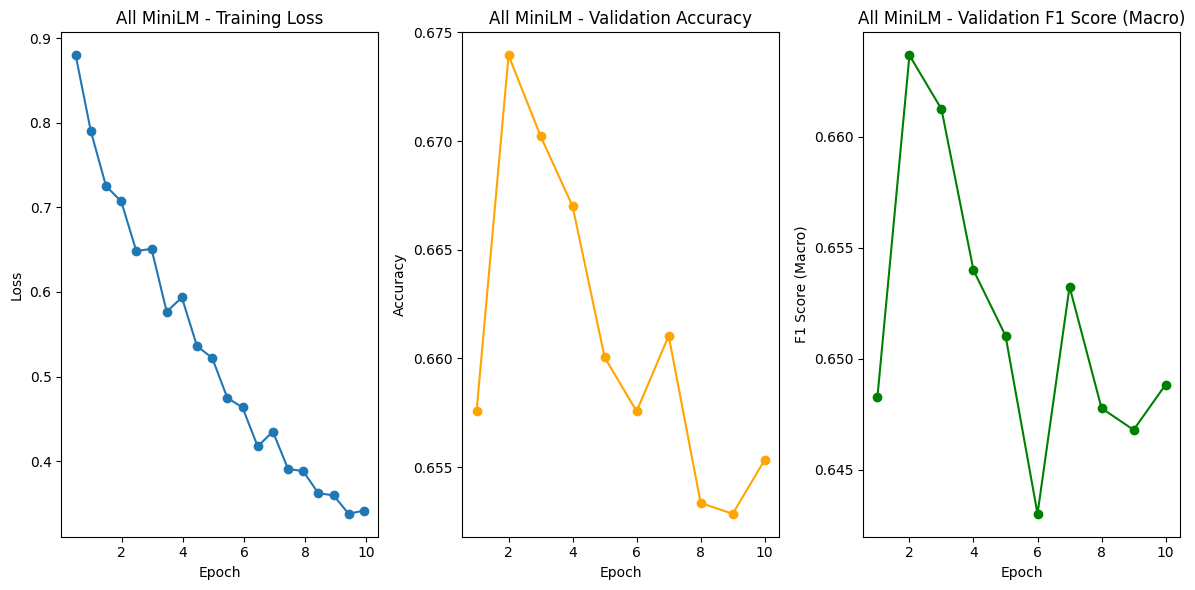

In [16]:
# Plot training loss, validation accuracy, and validation F1 score
import matplotlib.pyplot as plt

def plot_training_results(trainer, title):
    train_loss = trainer.state.log_history

    # Collect (epoch, value) pairs for each metric
    loss_points = [(log["epoch"], log["loss"]) for log in train_loss if "epoch" in log and "loss" in log]
    acc_points = [(log["epoch"], log["eval_accuracy"]) for log in train_loss if "epoch" in log and "eval_accuracy" in log]
    f1_points = [(log["epoch"], log["eval_f1_macro"]) for log in train_loss if "epoch" in log and "eval_f1_macro" in log]

    # Unzip to separate lists
    if loss_points:
        epochs_loss, losses = zip(*loss_points)
    else:
        epochs_loss, losses = [], []
    if acc_points:
        epochs_acc, eval_accuracy = zip(*acc_points)
    else:
        epochs_acc, eval_accuracy = [], []
    if f1_points:
        epochs_f1, eval_f1_macro = zip(*f1_points)
    else:
        epochs_f1, eval_f1_macro = [], []

    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_loss, losses, marker='o')
    plt.title(f'{title} - Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 3, 2)
    plt.plot(epochs_acc, eval_accuracy, marker='o', color='orange')
    plt.title(f'{title} - Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(1, 3, 3)
    plt.plot(epochs_f1, eval_f1_macro, marker='o', color='green')
    plt.title(f'{title} - Validation F1 Score (Macro)')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score (Macro)')

    plt.tight_layout()
    plt.savefig(f"../output/plots/reference/{title.replace(' ', '_').lower()}_training_results.eps", format='eps')
    plt.show()

plot_training_results(trainer_all, "All MiniLM")